Using device: cpu
Validation size: 23741

Loading ResNet50 Scratch...
✅ Model loaded successfully

Running inference...
Processed 20/371 (5.4%)
Processed 40/371 (10.8%)
Processed 60/371 (16.2%)
Processed 80/371 (21.6%)
Processed 100/371 (27.0%)
Processed 120/371 (32.3%)
Processed 140/371 (37.7%)
Processed 160/371 (43.1%)
Processed 180/371 (48.5%)
Processed 200/371 (53.9%)
Processed 220/371 (59.3%)
Processed 240/371 (64.7%)
Processed 260/371 (70.1%)
Processed 280/371 (75.5%)
Processed 300/371 (80.9%)
Processed 320/371 (86.3%)
Processed 340/371 (91.6%)
Processed 360/371 (97.0%)
Processed 371/371 (100.0%)

========== PER-CLASS METRICS ==========

Class: short sleeve top
Precision: 0.8783
Recall:    0.7002
F1 Score:  0.7792

Class: trousers
Precision: 0.8293
Recall:    0.8835
F1 Score:  0.8555

Class: shorts
Precision: 0.8062
Recall:    0.5867
F1 Score:  0.6792

Class: long sleeve top
Precision: 0.6175
Recall:    0.7045
F1 Score:  0.6581

Class: skirt
Precision: 0.7623
Recall:    0.6867
F1

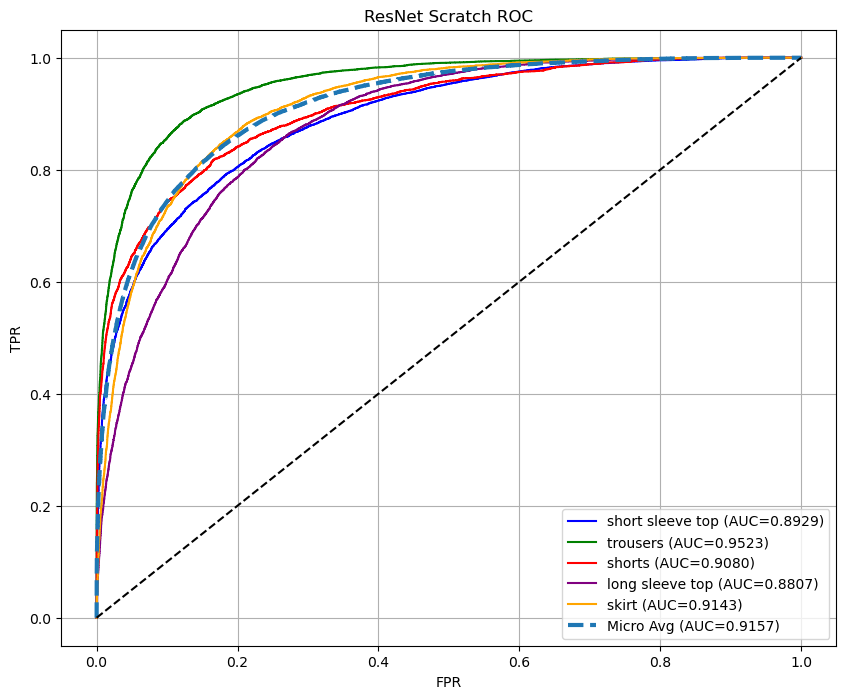


✅ Evaluation Complete


In [1]:
# ============================================================
# RESNET50 SCRATCH EVALUATION (FINAL - LOCAL)
# ============================================================

import os, json, torch, numpy as np
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= PATHS =================
BASE_DIR = "/Users/harshsinha/Desktop/iiitbSemester/sem6/vr/evaluation"

VAL_IMG = os.path.join(BASE_DIR, "validation/images")
VAL_ANN = os.path.join(BASE_DIR, "validation/annos")

MODEL_PATH = os.path.join(BASE_DIR, "pthFiles/ResNetScratch.pth")

# ================= LABEL MAP =================
LABEL_MAP = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

CLASS_NAMES = list(LABEL_MAP.keys())
NUM_CLASSES = 5

# ================= DATASET =================
class FashionDataset(Dataset):

    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(ann_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]
        json_path = os.path.join(self.ann_dir, file)
        img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            return torch.zeros((3,224,224)), torch.zeros(NUM_CLASSES)

        if self.transform:
            image = self.transform(image)

        with open(json_path) as f:
            data = json.load(f)

        target = torch.zeros(NUM_CLASSES)

        for key, val in data.items():
            if key.startswith("item"):
                cat = val["category_name"]
                if cat in LABEL_MAP:
                    target[LABEL_MAP[cat]] = 1.0

        return image, target

# ================= TRANSFORM =================
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# ================= DATA =================
val_dataset = FashionDataset(VAL_IMG, VAL_ANN, val_tf)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0   # ✅ Mac fix
)

print("Validation size:", len(val_dataset))

# ================= MODEL =================
print("\nLoading ResNet50 Scratch...")

model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

print("✅ Model loaded successfully")

# ================= INFERENCE =================
all_preds, all_labels, all_probs = [], [], []

print("\nRunning inference...")

total_batches = len(val_loader)

with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

        if (i+1) % 20 == 0 or (i+1) == total_batches:
            percent = (i+1)/total_batches * 100
            print(f"Processed {i+1}/{total_batches} ({percent:.1f}%)")

# Stack
all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# ================= PER-CLASS METRICS =================
print("\n========== PER-CLASS METRICS ==========")

for i, cls in enumerate(CLASS_NAMES):

    p = precision_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    r = recall_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    f = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)

    print(f"\nClass: {cls}")
    print(f"Precision: {p:.4f}")
    print(f"Recall:    {r:.4f}")
    print(f"F1 Score:  {f:.4f}")

# ================= OVERALL =================
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_rec  = recall_score(all_labels, all_preds, average='micro', zero_division=0)
micro_f1   = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n========== OVERALL ==========")
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_rec:.4f}")
print(f"Micro F1:        {micro_f1:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

# ================= ROC =================
print("\nPlotting ROC...")

plt.figure(figsize=(10,8))
colors = ['blue','green','red','purple','orange']

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(all_labels[:,i], all_probs[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i],
             label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.4f})")

# Micro
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, '--', lw=3,
         label=f"Micro Avg (AUC={roc_auc_micro:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ResNet Scratch ROC")
plt.legend()
plt.grid()

plt.savefig(os.path.join(BASE_DIR, "resnet_scratch_roc.png"))
plt.show()

print("\n✅ Evaluation Complete")